# Adversarial-Deconfounding Drug Response Model (AD-AE port)

Branched-encoder supervised regressor with a Gradient Reversal Layer adversary on the drug branch, ported from the AD-AE Keras code described in `AD_AE_ARCHITECTURE_CONTEXT.md`. Inputs, splits, metrics, and plots mirror notebook 4 so results are directly comparable; only the model and training loop change.

Design notes baked into this notebook:

- **Encoder is branched.** `Enc_ctx(baseline, dose)` carries cell-line-specific baseline state freely; `Enc_drug(fingerprint, dose)` is adversarially pushed to encode no cell-line identity. The predictor sees the fused representation.
- **Adversary attacks `z_drug` only.** `Enc_ctx` parameters receive zero gradient from adversarial CE (verified by a sanity-check cell). This preserves the modeling value of the baseline branch and matches the paper's intent of purifying only the learned latent that should be cell-line invariant.
- **λ is dynamic.** `λ_t = clamp(α · EMA(MSE_std) / EMA(CE), λ_min, λ_max)`. α is the real hyperparameter (target MSE:CE gradient ratio at steady state).
- **No explicit λ multiplier in the forward loss.** The GRL's `α` *is* `λ`. Writing `mse + λ·ce` while also using a GRL with `α=λ` would quadruple the encoder-side gradient magnitude — the §7 gotcha from the context doc, re-papered over by the PyTorch equivalent.
- **Early stopping monitors `val_treated_cosine` (max).** The joint loss is a min-max saddle and is non-monotone by construction; stopping on `val_loss` stops at meaningless points.

## Hyperparameters

In [1]:
from pathlib import Path

SPLIT_MODE = "drug_blind"  # one of {"drug_blind", "mixed"}; "tumor_blind" is rejected below
SPLIT_FRACTIONS = {"train": 0.8, "val": 0.1, "test": 0.1}
BATCH_SIZE = 512
RANDOM_SEED = 42
NUM_WORKERS = 0

MODEL_NAME = "adae"
CTX_BRANCH_HIDDEN_DIMS = (2048, 1024)
DRUG_BRANCH_HIDDEN_DIMS = (512, 128)
Z_CTX_DIM = 128
Z_DRUG_DIM = 64
FUSED_HIDDEN_DIMS = (512, 256)
PREDICTOR_HIDDEN_DIMS = (512,)
ADV_HIDDEN_DIMS = (100, 100)
CONFOUNDER_COLUMN = "cell_line"

ALPHA_TARGET = 0.1
EMA_MOMENTUM = 0.99
LAMBDA_MIN = 1e-3
LAMBDA_MAX = 10.0

TARGET_MODE = "delta"
PREPROCESS_BATCH_SIZE = 1024
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 5
EARLY_STOPPING_MONITOR = "val_treated_cosine"
EARLY_STOPPING_MODE = "max"
ACCELERATOR = "auto"
DEVICES = 1
PRECISION = "32-true"

PLOT_TEST_SAMPLE_COUNT = 50
PLOT_TEST_SAMPLE_STRATEGY = "seeded_random"
PLOT_RANDOM_SEED = RANDOM_SEED
EMBEDDING_METHOD = "pca"
N_EMBEDDING_COMPONENTS = 2

TENSOR_ARTIFACTS_DIR = Path("data/Tahoe100M_tensor_artifacts_L1000")
LIGHTNING_OUTPUT_DIR = Path("artifacts/lightning/adae")

print(
    {
        "SPLIT_MODE": SPLIT_MODE,
        "SPLIT_FRACTIONS": SPLIT_FRACTIONS,
        "BATCH_SIZE": BATCH_SIZE,
        "RANDOM_SEED": RANDOM_SEED,
        "NUM_WORKERS": NUM_WORKERS,
        "MODEL_NAME": MODEL_NAME,
        "CTX_BRANCH_HIDDEN_DIMS": CTX_BRANCH_HIDDEN_DIMS,
        "DRUG_BRANCH_HIDDEN_DIMS": DRUG_BRANCH_HIDDEN_DIMS,
        "Z_CTX_DIM": Z_CTX_DIM,
        "Z_DRUG_DIM": Z_DRUG_DIM,
        "FUSED_HIDDEN_DIMS": FUSED_HIDDEN_DIMS,
        "PREDICTOR_HIDDEN_DIMS": PREDICTOR_HIDDEN_DIMS,
        "ADV_HIDDEN_DIMS": ADV_HIDDEN_DIMS,
        "CONFOUNDER_COLUMN": CONFOUNDER_COLUMN,
        "ALPHA_TARGET": ALPHA_TARGET,
        "EMA_MOMENTUM": EMA_MOMENTUM,
        "LAMBDA_MIN": LAMBDA_MIN,
        "LAMBDA_MAX": LAMBDA_MAX,
        "TARGET_MODE": TARGET_MODE,
        "PREPROCESS_BATCH_SIZE": PREPROCESS_BATCH_SIZE,
        "LEARNING_RATE": LEARNING_RATE,
        "WEIGHT_DECAY": WEIGHT_DECAY,
        "MAX_EPOCHS": MAX_EPOCHS,
        "EARLY_STOPPING_PATIENCE": EARLY_STOPPING_PATIENCE,
        "EARLY_STOPPING_MONITOR": EARLY_STOPPING_MONITOR,
        "EARLY_STOPPING_MODE": EARLY_STOPPING_MODE,
    }
)


{'SPLIT_MODE': 'drug_blind', 'SPLIT_FRACTIONS': {'train': 0.8, 'val': 0.1, 'test': 0.1}, 'BATCH_SIZE': 512, 'RANDOM_SEED': 42, 'NUM_WORKERS': 0, 'MODEL_NAME': 'adae', 'CTX_BRANCH_HIDDEN_DIMS': (2048, 1024), 'DRUG_BRANCH_HIDDEN_DIMS': (512, 128), 'Z_CTX_DIM': 128, 'Z_DRUG_DIM': 64, 'FUSED_HIDDEN_DIMS': (512, 256), 'PREDICTOR_HIDDEN_DIMS': (512,), 'ADV_HIDDEN_DIMS': (100, 100), 'CONFOUNDER_COLUMN': 'cell_line', 'ALPHA_TARGET': 0.1, 'EMA_MOMENTUM': 0.99, 'LAMBDA_MIN': 0.001, 'LAMBDA_MAX': 10.0, 'TARGET_MODE': 'delta', 'PREPROCESS_BATCH_SIZE': 1024, 'LEARNING_RATE': 0.001, 'WEIGHT_DECAY': 0.0001, 'MAX_EPOCHS': 50, 'EARLY_STOPPING_PATIENCE': 5, 'EARLY_STOPPING_MONITOR': 'val_treated_cosine', 'EARLY_STOPPING_MODE': 'max'}


## Imports and Helpers

In [2]:
import math
import sys
import warnings
from pathlib import Path

import lightning as L
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from IPython.display import display
from lightning.pytorch.callbacks import EarlyStopping, ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score

for candidate_root in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (candidate_root / "pyproject.toml").exists() and (candidate_root / "Machine_Learning" / "ml_pipeline").exists():
        candidate_root_str = str(candidate_root)
        if candidate_root_str not in sys.path:
            sys.path.insert(0, candidate_root_str)
        break
else:
    raise ModuleNotFoundError(
        "Could not resolve the project root needed to import Machine_Learning.ml_pipeline."
    )

from Machine_Learning.ml_pipeline.data import DrugResponseDataModule, TrainingPreprocessor
from Machine_Learning.ml_pipeline.models import MODEL_REGISTRY, ADAEDrugResponseModule, build_model
from Machine_Learning.ml_pipeline.utils import (
    SPLIT_NAMES,
    assign_group_blind_splits,
    assign_mixed_split,
    build_loss_history_table,
    build_overlap_diagnostics,
    build_prediction_pair_embedding,
    build_project_path,
    build_split_summary,
    count_trainable_parameters,
    estimate_adamw_memory_gb,
    evaluate_model_on_loader,
    load_cached_cell_line_metadata,
    load_lightning_metrics_table,
    resolve_project_path,
    resolve_target_gene_indices,
    sample_prediction_details,
    validate_plot_config,
    validate_split_assignments,
    validate_split_config,
    validate_training_config,
)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")


## Load Tensors and Supporting Metadata

In [3]:
validate_split_config(SPLIT_MODE, SPLIT_FRACTIONS)
validate_training_config(
    TARGET_MODE,
    PREPROCESS_BATCH_SIZE,
    LEARNING_RATE,
    WEIGHT_DECAY,
    MAX_EPOCHS,
    EARLY_STOPPING_PATIENCE,
)
validate_plot_config(
    PLOT_TEST_SAMPLE_COUNT,
    PLOT_TEST_SAMPLE_STRATEGY,
    EMBEDDING_METHOD,
    N_EMBEDDING_COMPONENTS,
)
if MODEL_NAME not in MODEL_REGISTRY:
    available_model_names = ", ".join(sorted(MODEL_REGISTRY))
    raise ValueError(f"Unsupported MODEL_NAME: {MODEL_NAME}. Available models: {available_model_names}")
if MODEL_NAME != "adae":
    raise ValueError("Notebook 7 requires MODEL_NAME='adae'.")

tensor_artifacts_dir = resolve_project_path(TENSOR_ARTIFACTS_DIR)
dmso_bundle = torch.load(tensor_artifacts_dir / "dmso_baselines.pt", map_location="cpu")
treatment_bundle = torch.load(tensor_artifacts_dir / "treatment_expressions.pt", map_location="cpu")
fingerprint_bundle = torch.load(tensor_artifacts_dir / "morgan_fingerprints.pt", map_location="cpu")

input_gene_ids = [str(gene_id) for gene_id in dmso_bundle["gene_ids"]]
target_gene_ids = [str(gene_id) for gene_id in treatment_bundle["gene_ids"]]
target_gene_indices = resolve_target_gene_indices(input_gene_ids, target_gene_ids)

treatment_feature_space = str(treatment_bundle.get("feature_space", "unknown"))
requested_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("requested_landmark_gene_ids", target_gene_ids)
]
available_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("available_landmark_gene_ids", target_gene_ids)
]
missing_landmark_gene_ids = [
    str(gene_id) for gene_id in treatment_bundle.get("missing_landmark_gene_ids", [])
]

if available_landmark_gene_ids and target_gene_ids != available_landmark_gene_ids:
    raise ValueError("Treatment target gene_ids do not match available_landmark_gene_ids metadata.")
if len(target_gene_indices) != len(target_gene_ids):
    raise ValueError("Resolved target gene indices do not match the saved treatment target width.")

cell_line_metadata_df, cell_line_metadata_arrow_path = load_cached_cell_line_metadata()
tensor_cell_lines = set(dmso_bundle["cell_lines"])
matched_cell_line_metadata_df = cell_line_metadata_df.loc[
    cell_line_metadata_df["cell_line"].isin(tensor_cell_lines)
].copy()
missing_cell_line_metadata = sorted(tensor_cell_lines - set(matched_cell_line_metadata_df["cell_line"]))
if missing_cell_line_metadata:
    raise ValueError(f"Missing cell-line metadata for: {missing_cell_line_metadata}")

examples_df = pd.DataFrame(
    {
        "condition_key": treatment_bundle["condition_keys"],
        "cell_line": treatment_bundle["cell_lines"],
        "file_name": treatment_bundle["file_names"],
        "drug": treatment_bundle["drug_names"],
        "concentration": treatment_bundle["concentrations"].cpu().numpy().astype(np.float32),
        "concentration_unit": treatment_bundle["concentration_units"],
        "target_index": np.arange(len(treatment_bundle["condition_keys"]), dtype=np.int64),
    }
)
examples_df["baseline_index"] = examples_df["cell_line"].map(dmso_bundle["cell_line_to_index"])
examples_df["fingerprint_index"] = examples_df["drug"].map(fingerprint_bundle["drug_to_index"])

if examples_df["condition_key"].duplicated().any():
    raise ValueError("condition_key values must be unique in the treatment bundle.")
if examples_df["baseline_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a DMSO baseline index.")
if examples_df["fingerprint_index"].isna().any():
    raise ValueError("Some treatment rows do not resolve to a Morgan fingerprint index.")

examples_df = examples_df.merge(
    matched_cell_line_metadata_df,
    on="cell_line",
    how="left",
    validate="many_to_one",
)
if examples_df[["cell_name", "organ"]].isna().any().any():
    raise ValueError("Some treatment rows do not resolve to cell-line metadata.")

examples_df[["baseline_index", "fingerprint_index", "target_index"]] = examples_df[[
    "baseline_index",
    "fingerprint_index",
    "target_index",
]].astype(int)

print(
    f"Loaded {len(examples_df)} treatment examples with {len(input_gene_ids)} input genes and {len(target_gene_ids)} target genes "
    f"({treatment_feature_space})."
)
display(examples_df.head())


Loaded 26696 treatment examples with 20061 input genes and 977 target genes (l1000_landmark_intersection).


,condition_key,cell_line,file_name,drug,concentration,concentration_unit,target_index,baseline_index,fingerprint_index,cell_name,organ
0,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.05,uM,0,0,118,A549,Lung
1,CVCL_0023|||(R)-Verapamil (hydrochloride)|||0....,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),0.50,uM,1,0,118,A549,Lung
2,CVCL_0023|||(R)-Verapamil (hydrochloride)|||5|...,CVCL_0023,CVCL_0023.h5ad,(R)-Verapamil (hydrochloride),5.00,uM,2,0,118,A549,Lung
3,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.05,uM,3,0,137,A549,Lung
4,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,CVCL_0023.h5ad,(S)-Crizotinib,0.50,uM,4,0,137,A549,Lung


## Split Examples and Build DataLoaders

Hard guardrail: `tumor_blind` is rejected. If val/test cell lines are entirely held out, the adversary has no cell-line labels to classify in training for those rows' natural classes, and there is no way to later probe whether `z_drug` leaked cell-line identity for the held-out cells. Use `drug_blind` or `mixed`.

In [4]:
if SPLIT_MODE == "tumor_blind":
    raise ValueError(
        "SPLIT_MODE='tumor_blind' is rejected by notebook 7: held-out cell lines make the "
        "adversarial deconfounding objective degenerate. Use 'drug_blind' or 'mixed'."
    )

if SPLIT_MODE == "drug_blind":
    split_mode_note = "drug_blind: entire drugs are held out from train."
    split_unit_column = "drug"
    split_assignments = assign_group_blind_splits(
        examples_df,
        group_col="drug",
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )
else:
    split_mode_note = "mixed: condition keys are held out, but every drug and cell line remains represented in train."
    split_unit_column = "condition_key"
    split_assignments = assign_mixed_split(
        examples_df,
        split_fractions=SPLIT_FRACTIONS,
        seed=RANDOM_SEED,
    )

split_examples_df = examples_df.copy()
split_examples_df["split"] = split_assignments.to_numpy()
validate_split_assignments(split_examples_df, SPLIT_MODE)

split_summary_df = build_split_summary(split_examples_df, SPLIT_FRACTIONS)
split_unit_summary_df = (
    split_examples_df.groupby("split")[split_unit_column]
    .nunique()
    .reindex(SPLIT_NAMES)
    .reset_index(name=f"unique_{split_unit_column}_count")
)
overlap_diagnostics_df = build_overlap_diagnostics(split_examples_df, SPLIT_MODE)

train_examples_df = split_examples_df.loc[split_examples_df["split"] == "train"].reset_index(drop=True)
val_examples_df = split_examples_df.loc[split_examples_df["split"] == "val"].reset_index(drop=True)
test_examples_df = split_examples_df.loc[split_examples_df["split"] == "test"].reset_index(drop=True)
split_sample_counts = {split_name: int((split_examples_df["split"] == split_name).sum()) for split_name in SPLIT_NAMES}

print(
    f"Using {SPLIT_MODE} split. {split_mode_note} Sample counts -> train: {split_sample_counts['train']}, "
    f"val: {split_sample_counts['val']}, test: {split_sample_counts['test']}."
)
display(split_summary_df)
display(split_unit_summary_df)
display(overlap_diagnostics_df)


Using drug_blind split. drug_blind: entire drugs are held out from train. Sample counts -> train: 21368, val: 2664, test: 2664.


,split,target_rows,row_count,requested_fraction,realized_fraction,unique_drugs,unique_cell_lines,unique_organs
0,train,21356,21368,0.8,0.80042,303,24,10
1,val,2670,2664,0.1,0.09979,37,24,10
2,test,2670,2664,0.1,0.09979,37,24,10


,split,unique_drug_count
0,train,303
1,val,37
2,test,37


,entity,pair,overlap_count
0,drug,train/val,0
1,drug,train/test,0
2,drug,val/test,0
3,condition_key,train/val,0
4,condition_key,train/test,0
5,condition_key,val/test,0
6,cell_line,train/val,24
7,cell_line,train/test,24
8,cell_line,val/test,24


## Fit the Training Preprocessor

In [5]:
training_preprocessor = TrainingPreprocessor(
    train_examples_df=train_examples_df,
    dmso_bundle=dmso_bundle,
    treatment_bundle=treatment_bundle,
    fingerprint_bundle=fingerprint_bundle,
    target_gene_indices=target_gene_indices,
    target_mode=TARGET_MODE,
    batch_size=PREPROCESS_BATCH_SIZE,
).fit()

preprocessor_summary_df = training_preprocessor.summary_frame()
display(preprocessor_summary_df)


,target_mode,train_examples,input_dim,input_gene_dim,target_gene_dim,fingerprint_dim,dose_log_mean,dose_log_std,baseline_std_min,delta_std_min
0,delta,21368,22110,20061,977,2048,-0.307488,0.816949,0.001,0.198753


## Confounder Prep

Build `cell_line_to_index` from the **training split only**, then assert that val/test cell lines are a subset. For `drug_blind` and `mixed` splits this is guaranteed by construction — the assertion turns a silent dictionary lookup bug into a loud failure. Also print the adversary's random and majority-class baselines so the training curves can be read against them.

In [6]:
train_cell_lines = sorted(train_examples_df[CONFOUNDER_COLUMN].unique().tolist())
if len(train_cell_lines) < 2:
    raise ValueError(
        f"Need at least 2 distinct {CONFOUNDER_COLUMN} values in train to fit a softmax+CE adversary, "
        f"found {len(train_cell_lines)}."
    )
cell_line_to_index = {cell_line: idx for idx, cell_line in enumerate(train_cell_lines)}
n_confounder_classes = len(cell_line_to_index)

val_unseen_cell_lines = sorted(set(val_examples_df[CONFOUNDER_COLUMN]) - set(cell_line_to_index))
test_unseen_cell_lines = sorted(set(test_examples_df[CONFOUNDER_COLUMN]) - set(cell_line_to_index))
if val_unseen_cell_lines or test_unseen_cell_lines:
    raise ValueError(
        f"val/test contain {CONFOUNDER_COLUMN} values not present in train: "
        f"val={val_unseen_cell_lines[:10]}, test={test_unseen_cell_lines[:10]}. "
        "This breaks the CE adversary. Use a non-tumor-blind split."
    )

confounder_distribution_rows = []
majority_baselines = {}
for split_name, split_frame in (("train", train_examples_df), ("val", val_examples_df), ("test", test_examples_df)):
    counts = split_frame[CONFOUNDER_COLUMN].value_counts()
    total = int(counts.sum())
    majority_baseline = float(counts.max() / total) if total else float("nan")
    majority_baselines[split_name] = majority_baseline
    confounder_distribution_rows.append(
        {
            "split": split_name,
            "n_rows": total,
            f"n_unique_{CONFOUNDER_COLUMN}": int(split_frame[CONFOUNDER_COLUMN].nunique()),
            "random_baseline_acc": 1.0 / n_confounder_classes,
            "majority_baseline_acc": majority_baseline,
            "majority_class": counts.idxmax() if not counts.empty else None,
        }
    )
confounder_distribution_df = pd.DataFrame(confounder_distribution_rows)

print(
    f"Adversary will classify over {n_confounder_classes} {CONFOUNDER_COLUMN} classes (random baseline = "
    f"{1.0 / n_confounder_classes:.4f}). Read val_adv_acc against random and majority baselines below."
)
display(confounder_distribution_df)


Adversary will classify over 24 cell_line classes (random baseline = 0.0417). Read val_adv_acc against random and majority baselines below.


,split,n_rows,n_unique_cell_line,random_baseline_acc,majority_baseline_acc,majority_class
0,train,21368,24,0.041667,0.042306,CVCL_0480
1,val,2664,24,0.041667,0.041667,CVCL_0023
2,test,2664,24,0.041667,0.041667,CVCL_0023


## Build the Lightning DataModule and Model

Shape assertions mirror notebook 4's cell 13. The data module threads `cell_line_to_index` into each `PreparedTreatmentDataset` so every batch carries `cell_line_index` (a `LongTensor`) — required by `ADAEDrugResponseModule._compute_losses`.

In [7]:
response_data_module = DrugResponseDataModule(
    train_examples_df=train_examples_df,
    val_examples_df=val_examples_df,
    test_examples_df=test_examples_df,
    preprocessor=training_preprocessor,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    seed=RANDOM_SEED,
    cell_line_to_index=cell_line_to_index,
)
response_data_module.setup()

input_feature_dim = training_preprocessor.input_dim
target_gene_dim = training_preprocessor.target_gene_dim

response_model = build_model(
    MODEL_NAME,
    gene_dim=target_gene_dim,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    delta_mean=training_preprocessor.delta_mean,
    delta_std=training_preprocessor.delta_std,
    input_gene_dim=training_preprocessor.input_gene_dim,
    drug_feature_dim=training_preprocessor.fingerprint_dim,
    dose_feature_dim=1,
    ctx_branch_hidden_dims=CTX_BRANCH_HIDDEN_DIMS,
    drug_branch_hidden_dims=DRUG_BRANCH_HIDDEN_DIMS,
    z_ctx_dim=Z_CTX_DIM,
    z_drug_dim=Z_DRUG_DIM,
    fused_hidden_dims=FUSED_HIDDEN_DIMS,
    predictor_hidden_dims=PREDICTOR_HIDDEN_DIMS,
    adv_hidden_dims=ADV_HIDDEN_DIMS,
    n_confounder_classes=n_confounder_classes,
    alpha_target=ALPHA_TARGET,
    ema_momentum=EMA_MOMENTUM,
    lambda_min=LAMBDA_MIN,
    lambda_max=LAMBDA_MAX,
)

prepared_train_batch = next(iter(response_data_module.train_eval_dataloader()))
if prepared_train_batch["input_features"].shape[1] != input_feature_dim:
    raise ValueError("Prepared input feature width does not match the expected model input dimension.")
if prepared_train_batch["gene_features"].shape[1] != training_preprocessor.input_gene_dim:
    raise ValueError("Prepared gene feature width does not match the normalized DMSO input dimension.")
if prepared_train_batch["drug_features"].shape[1] != training_preprocessor.fingerprint_dim:
    raise ValueError("Prepared drug feature width does not match the fingerprint dimension.")
if prepared_train_batch["dose_feature"].ndim != 2 or prepared_train_batch["dose_feature"].shape[1] != 1:
    raise ValueError("Prepared dose feature must be a 2D tensor with a single feature column.")
if prepared_train_batch["target_delta"].shape[1] != target_gene_dim:
    raise ValueError("Prepared target delta width does not match the target gene space.")
if "cell_line_index" not in prepared_train_batch:
    raise ValueError("Prepared batch is missing cell_line_index; the DataModule was not given cell_line_to_index.")
if prepared_train_batch["cell_line_index"].dtype != torch.long:
    raise ValueError("cell_line_index must be a LongTensor for F.cross_entropy.")

model_summary_df = pd.DataFrame(
    [
        {
            "model_family": MODEL_NAME,
            "input_feature_dim": int(input_feature_dim),
            "input_gene_dim": int(training_preprocessor.input_gene_dim),
            "target_gene_dim": int(target_gene_dim),
            "output_dim": int(response_model.output_dim),
            "z_ctx_dim": Z_CTX_DIM,
            "z_drug_dim": Z_DRUG_DIM,
            "n_confounder_classes": n_confounder_classes,
            "trainable_parameters": count_trainable_parameters(response_model),
            "estimated_adamw_memory_gb": estimate_adamw_memory_gb(response_model),
            "alpha_target": ALPHA_TARGET,
            "initial_grl_alpha": float(response_model.grl.alpha),
        }
    ]
)
prepared_batch_summary_df = pd.DataFrame(
    [
        {
            "gene_feature_shape": tuple(prepared_train_batch["gene_features"].shape),
            "drug_feature_shape": tuple(prepared_train_batch["drug_features"].shape),
            "dose_feature_shape": tuple(prepared_train_batch["dose_feature"].shape),
            "baseline_shape": tuple(prepared_train_batch["baseline_expression"].shape),
            "target_delta_shape": tuple(prepared_train_batch["target_delta"].shape),
            "cell_line_index_shape": tuple(prepared_train_batch["cell_line_index"].shape),
        }
    ]
)

print(
    f"{MODEL_NAME} model creates {count_trainable_parameters(response_model):,} trainable parameters."
)
display(model_summary_df)
display(prepared_batch_summary_df)


adae model creates 45,323,873 trainable parameters.


,model_family,input_feature_dim,input_gene_dim,target_gene_dim,output_dim,z_ctx_dim,z_drug_dim,n_confounder_classes,trainable_parameters,estimated_adamw_memory_gb,alpha_target,initial_grl_alpha
0,adae,22110,20061,977,977,128,64,24,45323873,0.675378,0.1,0.1


,gene_feature_shape,drug_feature_shape,dose_feature_shape,baseline_shape,target_delta_shape,cell_line_index_shape
0,"(512, 20061)","(512, 2048)","(512, 1)","(512, 977)","(512, 977)","(512,)"


## GRL Direction Sanity Check

The single worst silent bug in an AD-AE port is a miswired Gradient Reversal Layer. Here we:

1. Do one forward pass on a held-out model clone with `grl.alpha = 1.0`, then backward through the **adversary CE only**.
2. Assert `Enc_ctx` receives **zero** gradient (adversary never sees `z_ctx`).
3. Assert `Enc_drug`'s first linear receives **nonzero** gradient.
4. Compare against a second pass where the GRL is bypassed (identity). The encoder-side gradient must point in the **opposite** direction under GRL (cosine < 0).

Hard-fails on any violation.

In [8]:
import copy

sanity_model = copy.deepcopy(response_model)
sanity_model.train()
sanity_model.grl.alpha = 1.0

sanity_inputs = {
    "gene_features": prepared_train_batch["gene_features"].detach().clone(),
    "drug_features": prepared_train_batch["drug_features"].detach().clone(),
    "dose_feature": prepared_train_batch["dose_feature"].detach().clone(),
}
sanity_labels = prepared_train_batch["cell_line_index"].detach().clone()

def _encoder_drug_first_linear(model):
    for module in model.encoder_drug:
        if isinstance(module, torch.nn.Linear):
            return module
    raise RuntimeError("Could not locate encoder_drug's first Linear layer.")

first_drug_linear_with_grl = _encoder_drug_first_linear(sanity_model)

for parameter in sanity_model.parameters():
    if parameter.grad is not None:
        parameter.grad.zero_()

z_ctx_grl, z_drug_grl, _ = sanity_model.latent_embeddings(sanity_inputs)
adv_logits_grl = sanity_model.adversary_head(sanity_model.grl(z_drug_grl))
adv_ce_grl = torch.nn.functional.cross_entropy(adv_logits_grl, sanity_labels)
adv_ce_grl.backward()

encoder_ctx_grad_norms = []
for name, parameter in sanity_model.encoder_ctx.named_parameters():
    grad = parameter.grad
    grad_norm = 0.0 if grad is None else float(grad.norm().item())
    encoder_ctx_grad_norms.append((name, grad_norm))
max_ctx_grad_norm = max((g for _, g in encoder_ctx_grad_norms), default=0.0)
if max_ctx_grad_norm > 1e-7:
    raise RuntimeError(
        f"Enc_ctx received nonzero gradient from adversary CE (max norm = {max_ctx_grad_norm:.3e}). "
        "The adversary must not see z_ctx."
    )

drug_grad_with_grl = first_drug_linear_with_grl.weight.grad.detach().clone()
if drug_grad_with_grl.norm().item() <= 1e-12:
    raise RuntimeError("Enc_drug received zero gradient from adversary CE — GRL may be disconnected.")

# Compare against a no-GRL reference (identity replaces the GRL so grad flows with natural sign)
reference_model = copy.deepcopy(response_model)
reference_model.train()
reference_model.grl = torch.nn.Identity()
first_drug_linear_no_grl = _encoder_drug_first_linear(reference_model)

for parameter in reference_model.parameters():
    if parameter.grad is not None:
        parameter.grad.zero_()

_, z_drug_ref, _ = reference_model.latent_embeddings(sanity_inputs)
adv_logits_ref = reference_model.adversary_head(reference_model.grl(z_drug_ref))
adv_ce_ref = torch.nn.functional.cross_entropy(adv_logits_ref, sanity_labels)
adv_ce_ref.backward()

drug_grad_no_grl = first_drug_linear_no_grl.weight.grad.detach().clone()
if drug_grad_no_grl.norm().item() <= 1e-12:
    raise RuntimeError("Reference (no-GRL) Enc_drug gradient is zero; sanity comparison cannot proceed.")

flat_with_grl = drug_grad_with_grl.flatten()
flat_no_grl = drug_grad_no_grl.flatten()
cos_sim = float(
    torch.nn.functional.cosine_similarity(flat_with_grl, flat_no_grl, dim=0).item()
)
if cos_sim >= 0:
    raise RuntimeError(
        f"GRL direction check failed: cosine(Enc_drug grad with GRL, without GRL) = {cos_sim:.4f} >= 0. "
        "The GRL is not reversing the encoder gradient."
    )

grl_sanity_df = pd.DataFrame(
    [
        {
            "max_encoder_ctx_grad_norm": max_ctx_grad_norm,
            "encoder_drug_grad_norm_with_grl": float(drug_grad_with_grl.norm().item()),
            "encoder_drug_grad_norm_no_grl": float(drug_grad_no_grl.norm().item()),
            "cosine_sim_grl_vs_identity": cos_sim,
            "passed": True,
        }
    ]
)
print("GRL sanity check passed: Enc_ctx grad = 0, Enc_drug grad nonzero with sign flipped vs identity.")
display(grl_sanity_df)
del sanity_model, reference_model


GRL sanity check passed: Enc_ctx grad = 0, Enc_drug grad nonzero with sign flipped vs identity.


,max_encoder_ctx_grad_norm,encoder_drug_grad_norm_with_grl,encoder_drug_grad_norm_no_grl,cosine_sim_grl_vs_identity,passed
0,0.0,0.030977,0.030977,-1.000129,True


## Dynamic-λ Bootstrap Sanity Check

Compute the would-be initial `λ = α · MSE_std / CE` on one train batch. Warn loudly if it's already clipped at `LAMBDA_MIN`/`LAMBDA_MAX` at init — the feedback loop will never get authority in that regime.

In [9]:
response_model.eval()
with torch.no_grad():
    sanity_batch = {
        "gene_features": prepared_train_batch["gene_features"],
        "drug_features": prepared_train_batch["drug_features"],
        "dose_feature": prepared_train_batch["dose_feature"],
    }
    z_ctx_init, z_drug_init, z_fused_init, standardized_delta_pred_init = response_model._forward_encoder_predictor(
        sanity_batch
    )
    target_delta_init = prepared_train_batch["target_delta"]
    standardized_delta_target_init = (target_delta_init - response_model.delta_mean) / response_model.delta_std
    predictor_mse_std_init = torch.nn.functional.mse_loss(
        standardized_delta_pred_init, standardized_delta_target_init
    )
    adv_logits_init = response_model.adversary_head(response_model.grl(z_drug_init))
    adv_ce_init = torch.nn.functional.cross_entropy(
        adv_logits_init, prepared_train_batch["cell_line_index"]
    )
    adv_acc_init = (
        (adv_logits_init.argmax(dim=1) == prepared_train_batch["cell_line_index"]).float().mean()
    )
response_model.train()

raw_ratio = (
    ALPHA_TARGET
    * float(predictor_mse_std_init.item())
    / max(float(adv_ce_init.item()), 1e-8)
)
lambda_init = max(LAMBDA_MIN, min(LAMBDA_MAX, raw_ratio))
was_clipped = (raw_ratio != lambda_init)

lambda_sanity_df = pd.DataFrame(
    [
        {
            "predictor_mse_std_init": float(predictor_mse_std_init.item()),
            "adv_ce_init": float(adv_ce_init.item()),
            "adv_acc_init": float(adv_acc_init.item()),
            "random_baseline_acc": 1.0 / n_confounder_classes,
            "alpha_target": ALPHA_TARGET,
            "raw_ratio_alpha_mse_over_ce": raw_ratio,
            "lambda_init_after_clamp": lambda_init,
            "clipped_at_bounds": bool(was_clipped),
            "lambda_min": LAMBDA_MIN,
            "lambda_max": LAMBDA_MAX,
        }
    ]
)
display(lambda_sanity_df)

soft_lower = ALPHA_TARGET * 0.1
soft_upper = ALPHA_TARGET * 10.0
if was_clipped:
    warnings.warn(
        f"Initial λ was clipped to bounds (raw={raw_ratio:.4e}, clamped={lambda_init:.4e}). "
        "The dynamic-λ feedback loop may not have authority; consider widening LAMBDA_MIN/LAMBDA_MAX "
        "or adjusting ALPHA_TARGET."
    )
elif not (soft_lower <= lambda_init <= soft_upper):
    warnings.warn(
        f"Initial λ ({lambda_init:.4e}) lies outside the soft sanity band [α·0.1, α·10] = "
        f"[{soft_lower:.4e}, {soft_upper:.4e}]. "
        "Training will start far from the intended steady state; expect a few epochs of drift."
    )
else:
    print(f"Initial λ = {lambda_init:.4e} lies inside the soft sanity band [α·0.1, α·10].")


,predictor_mse_std_init,adv_ce_init,adv_acc_init,random_baseline_acc,alpha_target,raw_ratio_alpha_mse_over_ce,lambda_init_after_clamp,clipped_at_bounds,lambda_min,lambda_max
0,0.696125,3.181997,0.0,0.041667,0.1,0.021877,0.021877,False,0.001,10.0


Initial λ = 2.1877e-02 lies inside the soft sanity band [α·0.1, α·10].


## Train with PyTorch Lightning

Checkpoint + early-stopping monitor default to `val_treated_cosine` (mode `max`). The joint loss is *never* the monitor — it is a saddle and non-monotone in val.

In [10]:
L.seed_everything(RANDOM_SEED, workers=True)

lightning_output_dir = build_project_path(LIGHTNING_OUTPUT_DIR)
lightning_output_dir.mkdir(parents=True, exist_ok=True)
run_name = f"{SPLIT_MODE}_{MODEL_NAME}_{TARGET_MODE}"

csv_logger = CSVLogger(save_dir=str(lightning_output_dir), name=run_name)
checkpoint_dir = lightning_output_dir / run_name / "checkpoints"
checkpoint_dir.mkdir(parents=True, exist_ok=True)

monitor_placeholder = (
    f"{EARLY_STOPPING_MONITOR}=" + "{" + EARLY_STOPPING_MONITOR + ":.6f}"
)
checkpoint_callback = ModelCheckpoint(
    dirpath=str(checkpoint_dir),
    filename="epoch={epoch:02d}-" + monitor_placeholder,
    monitor=EARLY_STOPPING_MONITOR,
    mode=EARLY_STOPPING_MODE,
    save_top_k=1,
)
early_stopping_callback = EarlyStopping(
    monitor=EARLY_STOPPING_MONITOR,
    mode=EARLY_STOPPING_MODE,
    patience=EARLY_STOPPING_PATIENCE,
)

trainer = L.Trainer(
    accelerator=ACCELERATOR,
    devices=DEVICES,
    precision=PRECISION,
    max_epochs=MAX_EPOCHS,
    logger=csv_logger,
    callbacks=[checkpoint_callback, early_stopping_callback],
    log_every_n_steps=max(1, math.ceil(len(train_examples_df) / BATCH_SIZE / 10)),
    deterministic=False,
)

trainer.fit(response_model, datamodule=response_data_module)
validation_results = trainer.validate(response_model, datamodule=response_data_module, ckpt_path="best", verbose=False)
test_results = trainer.test(response_model, datamodule=response_data_module, ckpt_path="best", verbose=False)

best_model_path = checkpoint_callback.best_model_path
if not best_model_path:
    raise ValueError("Lightning did not produce a best checkpoint path.")

best_checkpoint_state = torch.load(best_model_path, map_location="cpu")
response_model.load_state_dict(best_checkpoint_state["state_dict"])
metrics_csv_path = Path(csv_logger.log_dir) / "metrics.csv"

training_run_summary_df = pd.DataFrame(
    [
        {
            "best_model_path": str(best_model_path),
            "metrics_csv_path": str(metrics_csv_path),
            "best_monitor_value": float(checkpoint_callback.best_model_score.item()),
            "monitor": EARLY_STOPPING_MONITOR,
            "mode": EARLY_STOPPING_MODE,
            "logger_dir": str(csv_logger.log_dir),
            "current_epoch": int(trainer.current_epoch),
            "run_name": run_name,
            "final_lambda_adv": float(response_model.grl.alpha),
        }
    ]
)

display(training_run_summary_df)
display(pd.DataFrame(validation_results))
display(pd.DataFrame(test_results))


Seed set to 42
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type                  ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder_ctx    │ Sequential            │ 43.3 M │ train │     0 │
│ 1 │ encoder_drug   │ Sequential            │  1.1 M │ train │     0 │
│ 2 │ fuser          │ Sequential            │  230 K │ train │     0 │
│ 3 │ predictor_head │ Sequential            │  632 K │ train │     0 │
│ 4 │ grl            │ GradientReversalLayer │      0 │ train │     0 │
│ 5 │ adversary_head │ Sequential            │ 19.0 K │ train │     0 │
└───┴────────────────┴───────────────────────┴────────┴───────┴───────┘

Trainable params: 45.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 45.3 M                                                                                               
Total estimated model params size (MB): 181                                                                        
Modules in train mode: 27                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/utilities
/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

...

Restoring states from the checkpoint path at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae/drug_blind_adae_delta/checkpoints/epoch=epoch=02-val_treated_cosine=val_treated_cosine=0.981929.ckpt
Loaded model weights from the checkpoint at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae/drug_blind_adae_delta/checkpoints/epoch=epoch=02-val_treated_cosine=val_treated_cosine=0.981929.ckpt


Restoring states from the checkpoint path at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae/drug_blind_adae_delta/checkpoints/epoch=epoch=02-val_treated_cosine=val_treated_cosine=0.981929.ckpt
Loaded model weights from the checkpoint at /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae/drug_blind_adae_delta/checkpoints/epoch=epoch=02-val_treated_cosine=val_treated_cosine=0.981929.ckpt
/Users/liamwilson/dl_fin/deep-learning-final-project/.venv/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


,best_model_path,metrics_csv_path,best_monitor_value,monitor,mode,logger_dir,current_epoch,run_name,final_lambda_adv
0,/Users/liamwilson/dl_fin/deep-learning-final-p...,/Users/liamwilson/dl_fin/deep-learning-final-p...,0.981929,val_treated_cosine,max,/Users/liamwilson/dl_fin/deep-learning-final-p...,8,drug_blind_adae_delta,0.017854


,val_loss,val_predictor_mse_std,val_adv_ce,val_adv_acc,val_lambda_adv,val_delta_mse,val_delta_mae,val_treated_cosine
0,4.164491,0.985714,3.178777,0.041667,0.017854,705.256348,9.003819,0.981929


,test_loss,test_predictor_mse_std,test_adv_ce,test_adv_acc,test_lambda_adv,test_delta_mse,test_delta_mae,test_treated_cosine
0,4.04901,0.870193,3.178816,0.041667,0.017854,666.471497,8.241824,0.984266


## Evaluate the Best Checkpoint

Reuses `evaluate_model_on_loader` from `ml_pipeline/utils.py` unchanged so every row-level metric (delta MSE/MAE, treated cosine, Mann-Whitney, DEG overlap, signed nDCG@50) is computed identically to notebook 4.

In [11]:
evaluation_rows = []
inspection_tables = {}
prediction_detail_tables = {}
evaluation_loaders = {
    "train": response_data_module.train_eval_dataloader(),
    "val": response_data_module.val_dataloader(),
    "test": response_data_module.test_dataloader(),
}

for split_name, loader in evaluation_loaders.items():
    metrics_row, inspection_df, prediction_details_df = evaluate_model_on_loader(
        model=response_model,
        loader=loader,
        split_name=split_name,
        gene_ids=target_gene_ids,
    )
    evaluation_rows.append(metrics_row)
    inspection_tables[split_name] = inspection_df
    prediction_detail_tables[split_name] = prediction_details_df

evaluation_summary_df = pd.DataFrame(evaluation_rows)
test_prediction_details_df = prediction_detail_tables["test"].copy()
print(f"Evaluated best checkpoint from {best_model_path}")
display(evaluation_summary_df)
display(inspection_tables["test"])
display(test_prediction_details_df.head())


Evaluated best checkpoint from /Users/liamwilson/dl_fin/deep-learning-final-project/artifacts/lightning/adae/drug_blind_adae_delta/checkpoints/epoch=epoch=02-val_treated_cosine=val_treated_cosine=0.981929.ckpt


,split,n_samples,delta_mse,delta_mae,treated_cosine,mann_whitney_u_median,mann_whitney_pvalue_mean,mann_whitney_pvalue_median,mann_whitney_not_significant_fraction,top50_deg_match_count_mean,top50_deg_match_count_median,top50_deg_match_fraction_mean,top50_deg_match_fraction_median,signed_ndcg_at_50_mean,signed_ndcg_at_50_median
0,train,21368,510.735864,7.243964,0.976778,479883.0,0.327110,0.230191,0.713216,27.560371,27.0,0.551207,0.54,0.660418,0.689653
1,val,2664,705.256305,9.003819,0.981929,476272.5,0.216275,0.053001,0.504880,24.174550,24.0,0.483491,0.48,0.508773,0.546617
2,test,2664,666.471477,8.241825,0.984266,475715.0,0.256240,0.101209,0.572072,25.205706,25.0,0.504114,0.50,0.558888,0.596970


,split,condition_key,cell_line,drug,concentration,sample_delta_mse,sample_treated_cosine,sample_mann_whitney_u,sample_mann_whitney_pvalue,sample_top50_deg_match_count,...,pred_ENSG00000000003,target_ENSG00000000003,pred_ENSG00000000457,target_ENSG00000000457,pred_ENSG00000002330,target_ENSG00000002330,pred_ENSG00000002549,target_ENSG00000002549,pred_ENSG00000002919,target_ENSG00000002919
0,test,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,(S)-Crizotinib,0.05,177.160278,0.980263,496481.0,0.123331,35.0,...,3.340670,4.257095,3.783648,2.587646,3.413460,3.923205,28.572374,23.706177,4.598004,3.255426
1,test,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,(S)-Crizotinib,0.50,68.150330,0.992803,497094.0,0.111813,26.0,...,3.390664,2.905129,3.949444,3.449841,3.457745,3.540627,28.990038,28.960508,4.682873,5.356332
2,test,CVCL_0023|||(S)-Crizotinib|||5|||uM,CVCL_0023,(S)-Crizotinib,5.00,115.163834,0.989612,492937.0,0.208845,27.0,...,3.466512,3.122290,4.276931,3.295750,3.596354,3.989592,29.727859,26.366001,4.884713,4.336514


,split,dataset_index,condition_key,cell_line,cell_name,organ,drug,concentration,concentration_unit,delta_mse,delta_mae,treated_mse,treated_cosine,mann_whitney_u,mann_whitney_pvalue,top50_deg_match_count,top50_deg_match_fraction,signed_ndcg_at_50
0,test,0,CVCL_0023|||(S)-Crizotinib|||0.05|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,0.05,uM,177.160278,5.332895,177.160278,0.980263,496481.0,0.123331,35.0,0.70,0.922734
1,test,1,CVCL_0023|||(S)-Crizotinib|||0.5|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,0.50,uM,68.150330,3.309594,68.150330,0.992803,497094.0,0.111813,26.0,0.52,0.764515
2,test,2,CVCL_0023|||(S)-Crizotinib|||5|||uM,CVCL_0023,A549,Lung,(S)-Crizotinib,5.00,uM,115.163834,4.471693,115.163834,0.989612,492937.0,0.208845,27.0,0.54,0.770846
3,test,3,CVCL_0023|||Abiraterone acetate|||0.05|||uM,CVCL_0023,A549,Lung,Abiraterone acetate,0.05,uM,203.224915,4.673546,203.224915,0.985429,497506.0,0.104560,27.0,0.54,0.740185
4,test,4,CVCL_0023|||Abiraterone acetate|||0.5|||uM,CVCL_0023,A549,Lung,Abiraterone acetate,0.50,uM,204.948837,4.680819,204.948807,0.981863,472082.0,0.677741,29.0,0.58,0.649381


## Plot Training Dynamics: Predictor Loss, Adversary Accuracy, and λ

Three panels:

1. Predictor MSE in standardized Δ space, train vs val.
2. Adversary accuracy, train vs val. Reference lines at `1/n_classes` (random) and the majority-class baseline. The expected signature of a working min-max: adversary accuracy rises during the first few epochs, then decays toward the random baseline as the encoder wins.
3. `lambda_adv` per epoch, with `LAMBDA_MIN`/`LAMBDA_MAX` reference lines.

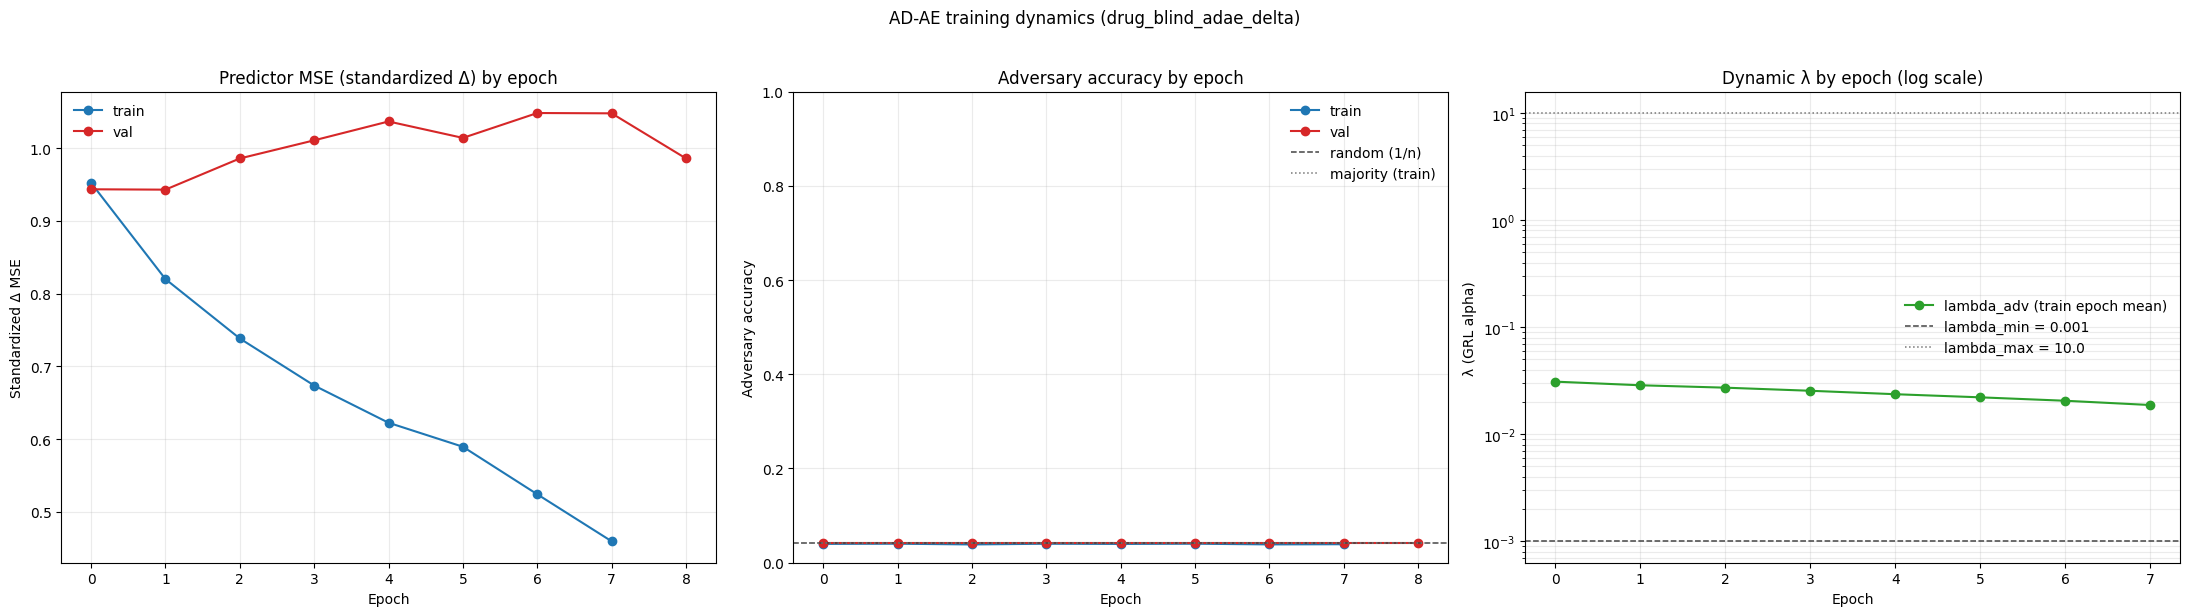

/var/folders/7m/f0pvhm5n0gzfwhjhkm63z0_40000gp/T/ipykernel_55499/3143118911.py:74: UserWarning: Final val_adv_acc is within ±0.05 of random/majority baseline. Adversarial pressure on z_drug may be vacuous because fingerprint+dose do not leak cell_line — this is the ideal deconfounding state, but double-check before tuning λ against it.
  warnings.warn(


In [12]:
lightning_metrics_df = load_lightning_metrics_table(metrics_csv_path)

def _collapse_per_epoch(metrics_df, column):
    if column not in metrics_df.columns:
        return pd.DataFrame(columns=["epoch", column])
    subset = metrics_df.loc[metrics_df[column].notna(), ["epoch", column]].copy()
    if subset.empty:
        return subset
    subset["epoch"] = subset["epoch"].astype(int)
    return subset.groupby("epoch", as_index=False)[column].last()

panel_series_frames = {
    ("train", "predictor_mse_std"): _collapse_per_epoch(lightning_metrics_df, "train_predictor_mse_std"),
    ("val", "predictor_mse_std"): _collapse_per_epoch(lightning_metrics_df, "val_predictor_mse_std"),
    ("train", "adv_acc"): _collapse_per_epoch(lightning_metrics_df, "train_adv_acc"),
    ("val", "adv_acc"): _collapse_per_epoch(lightning_metrics_df, "val_adv_acc"),
    ("train", "lambda_adv"): _collapse_per_epoch(lightning_metrics_df, "train_lambda_adv"),
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
loss_ax, adv_ax, lambda_ax = axes

for split_name, color in (("train", "#1f77b4"), ("val", "#d62728")):
    series = panel_series_frames[(split_name, "predictor_mse_std")]
    if not series.empty:
        loss_ax.plot(series["epoch"], series[f"{split_name}_predictor_mse_std"], marker="o", color=color, label=split_name)
loss_ax.set_title("Predictor MSE (standardized Δ) by epoch")
loss_ax.set_xlabel("Epoch")
loss_ax.set_ylabel("Standardized Δ MSE")
loss_ax.grid(True, alpha=0.25)
loss_ax.legend(frameon=False)

for split_name, color in (("train", "#1f77b4"), ("val", "#d62728")):
    series = panel_series_frames[(split_name, "adv_acc")]
    if not series.empty:
        adv_ax.plot(series["epoch"], series[f"{split_name}_adv_acc"], marker="o", color=color, label=split_name)
adv_ax.axhline(1.0 / n_confounder_classes, color="#444444", linestyle="--", linewidth=1.1, label="random (1/n)")
adv_ax.axhline(majority_baselines.get("train", float("nan")), color="#777777", linestyle=":", linewidth=1.1, label="majority (train)")
adv_ax.set_title("Adversary accuracy by epoch")
adv_ax.set_xlabel("Epoch")
adv_ax.set_ylabel("Adversary accuracy")
adv_ax.set_ylim(0, 1)
adv_ax.grid(True, alpha=0.25)
adv_ax.legend(frameon=False)

lambda_series = panel_series_frames[("train", "lambda_adv")]
if not lambda_series.empty:
    lambda_ax.plot(
        lambda_series["epoch"],
        lambda_series["train_lambda_adv"],
        marker="o",
        color="#2ca02c",
        label="lambda_adv (train epoch mean)",
    )
lambda_ax.axhline(LAMBDA_MIN, color="#444444", linestyle="--", linewidth=1.1, label=f"lambda_min = {LAMBDA_MIN}")
lambda_ax.axhline(LAMBDA_MAX, color="#777777", linestyle=":", linewidth=1.1, label=f"lambda_max = {LAMBDA_MAX}")
lambda_ax.set_yscale("log")
lambda_ax.set_title("Dynamic λ by epoch (log scale)")
lambda_ax.set_xlabel("Epoch")
lambda_ax.set_ylabel("λ (GRL alpha)")
lambda_ax.grid(True, alpha=0.25, which="both")
lambda_ax.legend(frameon=False)

fig.suptitle(f"AD-AE training dynamics ({run_name})", y=1.02)
fig.tight_layout()
plt.show()

# Post-training diagnostic warnings
val_adv_series = panel_series_frames[("val", "adv_acc")]
if not val_adv_series.empty:
    final_val_adv = float(val_adv_series["val_adv_acc"].iloc[-1])
    near_baseline = abs(final_val_adv - max(1.0 / n_confounder_classes, majority_baselines.get("val", float("nan")))) <= 0.05
    if near_baseline:
        warnings.warn(
            "Final val_adv_acc is within ±0.05 of random/majority baseline. Adversarial pressure on z_drug "
            "may be vacuous because fingerprint+dose do not leak cell_line — this is the ideal deconfounding "
            "state, but double-check before tuning λ against it."
        )
    elif final_val_adv > 0.90:
        warnings.warn(
            f"Final val_adv_acc = {final_val_adv:.3f} is above 0.90. GRL may be clipped at LAMBDA_MIN or "
            "encoder lacks capacity to fool the adversary."
        )


## Plot Predicted vs Actual Test Pairs

Identical to notebook 4's PCA pair plot. The model's `.forward()` calls `predict_delta`, which bypasses the GRL and adversary — so this plot reflects predictor quality only.

Plotted 50 seeded_random test pairs with PCA using the best checkpoint.


,pair_index,condition_key,cell_line,drug,concentration,concentration_unit,treated_mse,delta_mse,treated_cosine,mann_whitney_u,mann_whitney_pvalue,top50_deg_match_count,top50_deg_match_fraction,signed_ndcg_at_50,pair_distance_2d
0,15,CVCL_0131|||Olanzapine|||5|||uM,CVCL_0131,Olanzapine,5.00,uM,5375.548828,5375.548828,0.959185,356442.0,3.365438e-22,24.0,0.48,0.003306,2014.496582
1,42,CVCL_0480|||Relugolix|||5|||uM,CVCL_0480,Relugolix,5.00,uM,5486.787598,5486.787598,0.991563,378011.0,1.732334e-15,25.0,0.50,0.226304,1420.794800
2,26,CVCL_0332|||Omeprazole (sodium)|||5|||uM,CVCL_0332,Omeprazole (sodium),5.00,uM,1380.552490,1380.552490,0.996690,458099.0,1.243298e-01,32.0,0.64,0.526058,1037.563110
3,34,CVCL_0371|||Sapanisertib|||5|||uM,CVCL_0371,Sapanisertib,5.00,uM,1456.934937,1456.934692,0.979452,477826.0,9.641178e-01,27.0,0.54,0.342784,927.543030
4,32,CVCL_0371|||Everolimus|||5|||uM,CVCL_0371,Everolimus,5.00,uM,1009.957703,1009.957886,0.992907,532822.0,8.383749e-06,23.0,0.46,0.383274,671.847290
5,22,CVCL_0293|||Riluzole hydrochloride|||5|||uM,CVCL_0293,Riluzole hydrochloride,5.00,uM,2075.681152,2075.681396,0.981229,376859.0,8.176927e-16,20.0,0.40,0.120676,659.069153
6,24,CVCL_0332|||Diammonium Glycyrrhizinate|||0.5|||uM,CVCL_0332,Diammonium Glycyrrhizinate,0.50,uM,755.889709,755.889709,0.984360,479579.0,8.527890e-01,34.0,0.68,0.924521,657.557861
7,41,CVCL_0480|||Darinaparsin|||5|||uM,CVCL_0480,Darinaparsin,5.00,uM,1846.475098,1846.474976,0.979345,402377.0,1.910660e-09,31.0,0.62,0.748157,558.973755
8,25,CVCL_0332|||Fedratinib (hydrochloride hydrate)...,CVCL_0332,Fedratinib (hydrochloride hydrate),0.05,uM,664.441833,664.441833,0.989649,502708.0,4.132165e-02,28.0,0.56,0.734695,547.944702
9,27,CVCL_0334|||Demeclocycline|||5|||uM,CVCL_0334,Demeclocycline,5.00,uM,1078.997192,1078.997192,0.970224,411175.0,1.159754e-07,28.0,0.56,0.110332,443.273987


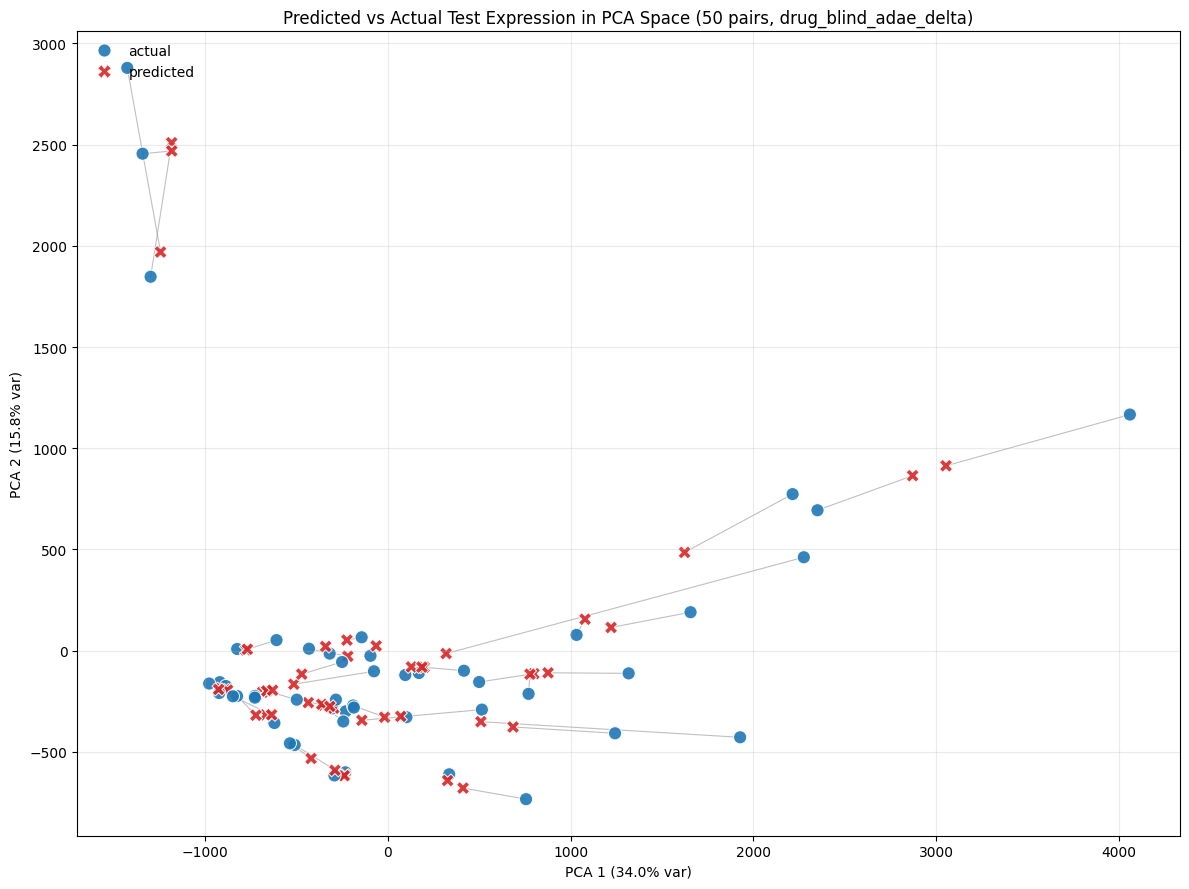

In [13]:
sampled_test_prediction_details_df = sample_prediction_details(
    prediction_details_df=test_prediction_details_df,
    sample_count=PLOT_TEST_SAMPLE_COUNT,
    sample_strategy=PLOT_TEST_SAMPLE_STRATEGY,
    random_seed=PLOT_RANDOM_SEED,
)
test_prediction_plot_df, sampled_test_pair_summary_df, test_embedding_explained_variance_ratio = build_prediction_pair_embedding(
    model=response_model,
    dataset=response_data_module.test_dataset,
    sampled_prediction_details_df=sampled_test_prediction_details_df,
    embedding_method=EMBEDDING_METHOD,
    n_components=N_EMBEDDING_COMPONENTS,
    random_seed=PLOT_RANDOM_SEED,
)

print(
    f"Plotted {len(sampled_test_prediction_details_df)} {PLOT_TEST_SAMPLE_STRATEGY} test pairs with {EMBEDDING_METHOD.upper()} using the best checkpoint."
)
display(sampled_test_pair_summary_df)

fig, ax = plt.subplots(figsize=(12, 9))
for pair_index, pair_points_df in test_prediction_plot_df.groupby("pair_index", sort=True):
    ordered_pair_points_df = pair_points_df.set_index("point_kind").loc[["actual", "predicted"]]
    ax.plot(
        ordered_pair_points_df["embedding_1"],
        ordered_pair_points_df["embedding_2"],
        color="#9e9e9e",
        linewidth=0.8,
        alpha=0.65,
        zorder=1,
    )
sns.scatterplot(
    data=test_prediction_plot_df,
    x="embedding_1",
    y="embedding_2",
    hue="point_kind",
    style="point_kind",
    palette={"actual": "#1f77b4", "predicted": "#d62728"},
    markers={"actual": "o", "predicted": "X"},
    s=90,
    alpha=0.9,
    ax=ax,
)
ax.set_title(
    f"Predicted vs Actual Test Expression in {EMBEDDING_METHOD.upper()} Space ({len(sampled_test_prediction_details_df)} pairs, {run_name})"
)
ax.set_xlabel(f"{EMBEDDING_METHOD.upper()} 1 ({test_embedding_explained_variance_ratio[0] * 100:.1f}% var)")
ax.set_ylabel(f"{EMBEDDING_METHOD.upper()} 2 ({test_embedding_explained_variance_ratio[1] * 100:.1f}% var)")
ax.grid(True, alpha=0.25)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
plt.show()


## Latent-Space Leakage Check: z_ctx vs z_drug Colored by Cell Line

Money plot. If AD-AE is working:

- `z_ctx` (left) should cluster strongly by cell line (expected — baseline expression *is* cell-line-specific).
- `z_drug` (right) should be near-uniform with respect to cell line (adversary was pushing it toward invariance).

A logistic regression linear probe from each full-dim latent to cell_line quantifies residual leakage. Train-only probe is reported to be fair (test embeddings drawn from training-cell-lines under the drug_blind/mixed split).

In [ ]:
def _collect_latents(model, dataset):
    model.eval()
    gene_list = []
    drug_list = []
    dose_list = []
    cell_line_list = []
    for idx in range(len(dataset)):
        example = dataset[idx]
        gene_list.append(example["gene_features"])
        drug_list.append(example["drug_features"])
        dose_list.append(example["dose_feature"])
        cell_line_list.append(example["cell_line"])
    stacked_inputs = {
        "gene_features": torch.stack(gene_list, dim=0),
        "drug_features": torch.stack(drug_list, dim=0),
        "dose_feature": torch.stack(dose_list, dim=0),
    }
    with torch.no_grad():
        z_ctx, z_drug, z_fused = model.latent_embeddings(stacked_inputs)
    return (
        z_ctx.detach().cpu().numpy(),
        z_drug.detach().cpu().numpy(),
        z_fused.detach().cpu().numpy(),
        np.asarray(cell_line_list),
    )

train_z_ctx, train_z_drug, _, train_cell_line_arr = _collect_latents(
    response_model, response_data_module.train_dataset
)
test_z_ctx, test_z_drug, _, test_cell_line_arr = _collect_latents(
    response_model, response_data_module.test_dataset
)

# 2D PCA is fit on the TEST embeddings for visual compactness.
pca_ctx = PCA(n_components=2, svd_solver="full").fit(test_z_ctx)
pca_drug = PCA(n_components=2, svd_solver="full").fit(test_z_drug)
test_z_ctx_2d = pca_ctx.transform(test_z_ctx)
test_z_drug_2d = pca_drug.transform(test_z_drug)

# Linear probe on full-dim latents: fit on train, evaluate on test.
def _linear_probe(train_z, train_labels, test_z, test_labels):
    classifier = LogisticRegression(max_iter=2000, n_jobs=None)
    classifier.fit(train_z, train_labels)
    test_pred = classifier.predict(test_z)
    return {
        "accuracy": float(np.mean(test_pred == test_labels)),
        "balanced_accuracy": float(balanced_accuracy_score(test_labels, test_pred)),
    }

probe_ctx = _linear_probe(train_z_ctx, train_cell_line_arr, test_z_ctx, test_cell_line_arr)
probe_drug = _linear_probe(train_z_drug, train_cell_line_arr, test_z_drug, test_cell_line_arr)
probe_summary_df = pd.DataFrame(
    [
        {"latent": "z_ctx", **probe_ctx},
        {"latent": "z_drug", **probe_drug},
        {"latent": "random_baseline", "accuracy": 1.0 / n_confounder_classes, "balanced_accuracy": 1.0 / n_confounder_classes},
        {"latent": "majority_baseline_test", "accuracy": majority_baselines["test"], "balanced_accuracy": float("nan")},
    ]
)
display(probe_summary_df)

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=False)
ctx_ax, drug_ax = axes

ctx_plot_df = pd.DataFrame({"pc1": test_z_ctx_2d[:, 0], "pc2": test_z_ctx_2d[:, 1], "cell_line": test_cell_line_arr})
drug_plot_df = pd.DataFrame({"pc1": test_z_drug_2d[:, 0], "pc2": test_z_drug_2d[:, 1], "cell_line": test_cell_line_arr})

sns.scatterplot(
    data=ctx_plot_df,
    x="pc1",
    y="pc2",
    hue="cell_line",
    s=30,
    alpha=0.75,
    ax=ctx_ax,
    legend=False,
)
ctx_ax.set_title(
    f"z_ctx (test) colored by cell_line — probe acc = {probe_ctx['accuracy']:.3f} (bal = {probe_ctx['balanced_accuracy']:.3f})"
)
ctx_ax.set_xlabel(f"PC1 ({pca_ctx.explained_variance_ratio_[0] * 100:.1f}% var)")
ctx_ax.set_ylabel(f"PC2 ({pca_ctx.explained_variance_ratio_[1] * 100:.1f}% var)")
ctx_ax.grid(True, alpha=0.25)

sns.scatterplot(
    data=drug_plot_df,
    x="pc1",
    y="pc2",
    hue="cell_line",
    s=30,
    alpha=0.75,
    ax=drug_ax,
    legend=False,
)
drug_ax.set_title(
    f"z_drug (test) colored by cell_line — probe acc = {probe_drug['accuracy']:.3f} (bal = {probe_drug['balanced_accuracy']:.3f})"
)
drug_ax.set_xlabel(f"PC1 ({pca_drug.explained_variance_ratio_[0] * 100:.1f}% var)")
drug_ax.set_ylabel(f"PC2 ({pca_drug.explained_variance_ratio_[1] * 100:.1f}% var)")
drug_ax.grid(True, alpha=0.25)

fig.suptitle("Latent deconfounding check: z_ctx vs z_drug", y=1.02)
fig.tight_layout()
plt.show()


## Plot Test Cell-Line Accuracy (Mann-Whitney)

In [ ]:
test_prediction_details_df = test_prediction_details_df.copy()
test_prediction_details_df["is_correct_prediction"] = test_prediction_details_df["mann_whitney_pvalue"] > 0.05

test_cell_line_accuracy_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        n_correct_predictions=("is_correct_prediction", "sum"),
    )
)
test_cell_line_accuracy_df["n_correct_predictions"] = test_cell_line_accuracy_df["n_correct_predictions"].astype(int)
test_cell_line_accuracy_df["cell_line_accuracy"] = (
    test_cell_line_accuracy_df["n_correct_predictions"] / test_cell_line_accuracy_df["n_test_samples"]
)
test_cell_line_accuracy_df = test_cell_line_accuracy_df.sort_values(
    ["cell_line_accuracy", "cell_line"],
    ascending=[False, True],
    ignore_index=True,
)
mean_cell_line_accuracy = float(test_cell_line_accuracy_df["cell_line_accuracy"].mean())

display(test_cell_line_accuracy_df)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=test_cell_line_accuracy_df,
    x="cell_line",
    y="cell_line_accuracy",
    color="#4c72b0",
    ax=ax,
)
ax.axhline(
    mean_cell_line_accuracy,
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean accuracy = {mean_cell_line_accuracy:.3f}",
)
ax.set_title("Test Cell-Line Accuracy from Mann-Whitney Non-Significance")
ax.set_xlabel("Cell line")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(True, axis="y", alpha=0.25)
ax.tick_params(axis="x", rotation=45)
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()


## Plot Test Cell-Line DEG Overlap Metrics

In [ ]:
test_cell_line_deg_match_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        mean_top50_deg_match_count=("top50_deg_match_count", "mean"),
        median_top50_deg_match_count=("top50_deg_match_count", "median"),
        min_top50_deg_match_count=("top50_deg_match_count", "min"),
        max_top50_deg_match_count=("top50_deg_match_count", "max"),
    )
    .sort_values(["median_top50_deg_match_count", "cell_line"], ascending=[False, True], ignore_index=True)
)
test_cell_line_signed_ndcg_df = (
    test_prediction_details_df.groupby("cell_line", as_index=False)
    .agg(
        n_test_samples=("condition_key", "size"),
        mean_signed_ndcg_at_50=("signed_ndcg_at_50", "mean"),
        median_signed_ndcg_at_50=("signed_ndcg_at_50", "median"),
        min_signed_ndcg_at_50=("signed_ndcg_at_50", "min"),
        max_signed_ndcg_at_50=("signed_ndcg_at_50", "max"),
    )
    .sort_values(["median_signed_ndcg_at_50", "cell_line"], ascending=[False, True], ignore_index=True)
)
deg_match_order = test_cell_line_deg_match_df["cell_line"].tolist()
signed_ndcg_order = test_cell_line_signed_ndcg_df["cell_line"].tolist()

display(test_cell_line_deg_match_df)
display(test_cell_line_signed_ndcg_df)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
deg_ax, ndcg_ax = axes

sns.boxplot(
    data=test_prediction_details_df,
    x="cell_line",
    y="top50_deg_match_count",
    order=deg_match_order,
    whis=(0, 100),
    color="#4c72b0",
    ax=deg_ax,
)
deg_ax.set_title("Test Cell-Line Top-50 DEG Overlap Counts")
deg_ax.set_xlabel("Cell line")
deg_ax.set_ylabel("Matched DEGs out of 50")
deg_ax.grid(True, axis="y", alpha=0.25)
deg_ax.tick_params(axis="x", rotation=45)

sns.boxplot(
    data=test_prediction_details_df,
    x="cell_line",
    y="signed_ndcg_at_50",
    order=signed_ndcg_order,
    whis=(0, 100),
    color="#55a868",
    ax=ndcg_ax,
)
ndcg_ax.set_title("Test Cell-Line Signed nDCG@50")
ndcg_ax.set_xlabel("Cell line")
ndcg_ax.set_ylabel("Signed nDCG@50")
ndcg_ax.set_ylim(0, 1)
ndcg_ax.grid(True, axis="y", alpha=0.25)
ndcg_ax.tick_params(axis="x", rotation=45)

fig.tight_layout()
plt.show()
